# ChurnZero Banking Customer Churn Prediction

## Objective
The objective of this project is to predict whether a banking customer will churn in the upcoming period using customer profile, banking relationship, transaction behavior, digital engagement, complaint history, and marketing response data.

## Business Context
The business cost of missing an actual churner is significantly higher than incorrectly flagging a non-churner. Therefore, the model is optimized using both statistical metrics and business-cost-based threshold tuning.

- False Negative cost: ₹40,000
- False Positive cost: ₹500

## Final Approach
The final solution uses a Random Forest classifier with preprocessing, missing value imputation, one-hot encoding for categorical variables, engineered behavioral features, and threshold optimization based on business cost.

## Key Evaluation Metrics
- PR-AUC
- F1-score
- Precision
- Recall
- Confusion Matrix
- Business Cost

In [1]:
import pandas as pd
import numpy as np

# Load files
train = pd.read_csv("ChurnZero_dataset_v1.csv")
test = pd.read_csv("ChurnZero_test_v1.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nFirst 5 rows:")
display(train.head())

print("\nColumns:")
print(train.columns.tolist())

Train shape: (8101, 98)
Test shape: (2026, 97)

First 5 rows:


,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
0,133001,0,36,Female,Married,Unknown,0,Salaried,22256,Low,...,0,Not Aware,Positive,1663,0.839,0.721,28420.0,33,0.0000,55.6
1,133002,1,44,Male,Single,High School,3,Homemaker,66481,Middle,...,1,High,Positive,4979,0.009,0.000,11501.0,19,0.0000,54.5
2,133003,0,46,Male,Married,High School,2,Salaried,98955,Upper-Middle,...,0,Low,Positive,8716,0.104,0.169,11619.0,31,0.0000,43.0
3,133004,0,36,Female,Married,Graduate,2,Retired,26735,Low,...,0,Medium,Neutral,2177,0.438,0.439,26458.0,29,0.5135,57.2
4,133005,0,50,Male,Single,Graduate,1,Salaried,165387,High,...,1,Low,Positive,15401,0.061,0.039,23938.0,22,0.2289,56.1



Columns:
['customer_id', 'churn', 'age', 'gender', 'marital_status', 'education_level', 'dependent_count', 'occupation_type', 'annual_income', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'tenure_months', 'onboarding_channel', 'relationship_type', 'number_of_products', 'primary_account_type', 'card_category', 'customer_lifetime_value', 'loyalty_program_member', 'referral_count', 'last_contacted_days', 'relationship_manager_assigned', 'avg_monthly_balance', 'current_balance', 'balance_decline_percentage', 'monthly_transaction_count', 'monthly_transaction_value', 'cash_withdrawal_count', 'upi_transaction_count', 'debit_card_transaction_count', 'net_banking_transaction_count', 'account_inactive_days', 'total_trans_amt', 'total_trans_count', 'total_amt_chng_q4_q1', 'total_ct_chng_q4_q1', 'avg_open_to_buy', 'total_revolving_bal', 'savings_account_flag', 'current_account_flag', 'credit_card_flag', 'personal_loan_flag', 'home_loan_flag', 'auto_loan_flag', 'fix

In [2]:
target = "churn"

print(train[target].value_counts())
print("\nChurn rate:")
print(train[target].mean())

churn
0    6799
1    1302
Name: count, dtype: int64

Churn rate:
0.1607208986544871


In [3]:
missing = train.isnull().mean().sort_values(ascending=False)
missing[missing > 0].head(20)

,0
app_rating_given,0.560548


In [4]:
X = train.drop(columns=["churn"])
y = train["churn"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:", len(cat_cols))
print(cat_cols)

print("\nNumerical columns:", len(num_cols))
print(num_cols[:20])

Categorical columns: 15
['gender', 'marital_status', 'education_level', 'occupation_type', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment']

Numerical columns: 82
['customer_id', 'age', 'dependent_count', 'annual_income', 'tenure_months', 'number_of_products', 'customer_lifetime_value', 'loyalty_program_member', 'referral_count', 'last_contacted_days', 'relationship_manager_assigned', 'avg_monthly_balance', 'current_balance', 'balance_decline_percentage', 'monthly_transaction_count', 'monthly_transaction_value', 'cash_withdrawal_count', 'upi_transaction_count', 'debit_card_transaction_count', 'net_banking_transaction_count']


In [8]:
id_col = "customer_id"

X = train.drop(columns=["churn", id_col])
y = train["churn"]

test_ids = test[id_col]
X_test = test.drop(columns=[id_col])

## Methodology

The dataset contains both numerical and categorical variables. Numerical features were imputed using the median, while categorical features were imputed using the most frequent category and encoded using one-hot encoding.

A stratified train-validation split was used to preserve the churn distribution in both training and validation sets. Since churn is an imbalanced classification problem, PR-AUC and F1-score were used instead of relying only on accuracy.

Feature engineering was performed to capture customer behavior patterns such as digital engagement, transaction decline, complaint intensity, credit stress, and relationship value.

The final threshold was selected using business cost:
Business Cost = False Negatives × ₹40,000 + False Positives × ₹500

This threshold optimization prioritizes reducing false negatives because missing an actual churner is much more expensive than incorrectly flagging a non-churner.

In [9]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# -----------------------------
# 1. Define target and ID column
# -----------------------------
target = "churn"
id_col = "customer_id"

X = train.drop(columns=[target, id_col])
y = train[target]

X_test_final = test.drop(columns=[id_col])

# -----------------------------
# 2. Identify column types
# -----------------------------
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

# -----------------------------
# 3. Train-validation split
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 4. Preprocessing
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# -----------------------------
# 5. Baseline Random Forest model
# -----------------------------
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

# -----------------------------
# 6. Train model
# -----------------------------
clf.fit(X_train, y_train)

# -----------------------------
# 7. Predict probabilities
# -----------------------------
val_probs = clf.predict_proba(X_val)[:, 1]

# Default threshold = 0.5
threshold = 0.5
val_preds = (val_probs >= threshold).astype(int)

# -----------------------------
# 8. Evaluation metrics
# -----------------------------
pr_auc = average_precision_score(y_val, val_probs)
f1 = f1_score(y_val, val_preds)
precision = precision_score(y_val, val_preds)
recall = recall_score(y_val, val_preds)

cm = confusion_matrix(y_val, val_preds)
tn, fp, fn, tp = cm.ravel()

business_cost = fn * 40000 + fp * 500

print("===== BASELINE MODEL RESULTS =====")
print("PR-AUC:", round(pr_auc, 4))
print("F1 Score:", round(f1, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Business Cost: ₹", business_cost)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_val, val_preds))

Number of numerical columns: 81
Number of categorical columns: 15
===== BASELINE MODEL RESULTS =====
PR-AUC: 0.9986
F1 Score: 0.9825
Precision: 1.0
Recall: 0.9655
Business Cost: ₹ 360000

Confusion Matrix:
[[1360    0]
 [   9  252]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1360
           1       1.00      0.97      0.98       261

    accuracy                           0.99      1621
   macro avg       1.00      0.98      0.99      1621
weighted avg       0.99      0.99      0.99      1621



In [10]:

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

threshold_results = []

for threshold in np.arange(0.05, 0.95, 0.01):
    preds = (val_probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()

    precision = precision_score(y_val, preds, zero_division=0)
    recall = recall_score(y_val, preds, zero_division=0)
    f1 = f1_score(y_val, preds, zero_division=0)

    business_cost = fn * 40000 + fp * 500

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "business_cost": business_cost
    })

threshold_df = pd.DataFrame(threshold_results)

# Sort by lowest business cost
threshold_df_sorted = threshold_df.sort_values(by="business_cost")

print("Top 10 thresholds by lowest business cost:")
display(threshold_df_sorted.head(10))

# Best threshold
best_threshold = threshold_df_sorted.iloc[0]["threshold"]
print("Best threshold:", round(best_threshold, 2))

Top 10 thresholds by lowest business cost:


,threshold,precision,recall,f1,tn,fp,fn,tp,business_cost
12,0.17,0.918728,0.996169,0.955882,1337,23,1,260,51500
11,0.16,0.909091,0.996169,0.950640,1334,26,1,260,53000
10,0.15,0.890411,0.996169,0.940325,1328,32,1,260,56000
3,0.08,0.697861,1.000000,0.822047,1247,113,0,261,56500
9,0.14,0.869565,0.996169,0.928571,1321,39,1,260,59500
8,0.13,0.849673,0.996169,0.917108,1314,46,1,260,63000
7,0.12,0.836013,0.996169,0.909091,1309,51,1,260,65500
6,0.11,0.807453,0.996169,0.891938,1298,62,1,260,71000
2,0.07,0.638142,1.000000,0.779104,1212,148,0,261,74000
5,0.10,0.769231,0.996169,0.868114,1282,78,1,260,79000


Best threshold: 0.17


In [11]:

best_threshold = 0.17

# Refit model on full training data
clf.fit(X, y)

# Predict probabilities for test data
test_probs = clf.predict_proba(X_test_final)[:, 1]

# Convert probabilities to 0/1 using best threshold
test_preds = (test_probs >= best_threshold).astype(int)

# Create final prediction file
submission = pd.DataFrame({
    "customer_id": test[id_col],
    "churn_prediction": test_preds,
    "churn_probability": test_probs
})

# Safety checks
print("Submission shape:", submission.shape)
print("Null values:")
print(submission.isnull().sum())

print("\nPrediction counts:")
print(submission["churn_prediction"].value_counts())

print("\nProbability range:")
print(submission["churn_probability"].min(), submission["churn_probability"].max())

# Save file
submission.to_csv("ChurnZero_Varun_Predictions.csv", index=False)

print("\nSaved file: ChurnZero_Varun_Predictions.csv")
display(submission.head())

Submission shape: (2026, 3)
Null values:
customer_id          0
churn_prediction     0
churn_probability    0
dtype: int64

Prediction counts:
churn_prediction
0    1672
1     354
Name: count, dtype: int64

Probability range:
0.0 1.0

Saved file: ChurnZero_Varun_Predictions.csv


,customer_id,churn_prediction,churn_probability
0,767114958,0,0.003333
1,708123033,0,0.030000
2,715424283,0,0.090000
3,717865008,0,0.003333
4,710188308,0,0.040000


In [12]:

def add_features(df):
    df = df.copy()

    # Safe denominator to avoid division by zero
    tenure_safe = df["tenure_months"].replace(0, 1)

    # Relationship value features
    if "customer_lifetime_value" in df.columns:
        df["clv_per_tenure"] = df["customer_lifetime_value"] / tenure_safe

    if "number_of_products" in df.columns:
        df["products_per_tenure"] = df["number_of_products"] / tenure_safe

    # Complaint intensity
    if "total_complaints" in df.columns:
        df["complaints_per_tenure"] = df["total_complaints"] / tenure_safe

    # Digital disengagement risk
    if "mobile_app_login_count" in df.columns and "internet_banking_login_count" in df.columns:
        df["total_digital_logins"] = (
            df["mobile_app_login_count"] + df["internet_banking_login_count"]
        )

    if "last_login_days" in df.columns and "mobile_app_login_count" in df.columns:
        df["login_gap_per_mobile_login"] = df["last_login_days"] / (df["mobile_app_login_count"] + 1)

    # Balance and transaction behavior
    if "avg_monthly_balance" in df.columns and "monthly_transaction_count" in df.columns:
        df["balance_per_transaction"] = df["avg_monthly_balance"] / (df["monthly_transaction_count"] + 1)

    if "balance_decline_percentage" in df.columns and "monthly_transaction_count" in df.columns:
        df["decline_per_transaction"] = df["balance_decline_percentage"] / (df["monthly_transaction_count"] + 1)

    # Credit stress
    if "credit_utilization_ratio" in df.columns and "late_credit_card_payment_count" in df.columns:
        df["credit_stress_score"] = (
            df["credit_utilization_ratio"] * (df["late_credit_card_payment_count"] + 1)
        )

    # Marketing pressure
    if "campaign_received_count" in df.columns and "retention_offer_accepted" in df.columns:
        df["campaigns_per_offer_acceptance"] = df["campaign_received_count"] / (df["retention_offer_accepted"] + 1)

    return df


# Apply feature engineering
train_fe = add_features(train)
test_fe = add_features(test)

# Recreate X, y, and test features
X_fe = train_fe.drop(columns=[target, id_col])
y_fe = train_fe[target]

X_test_fe = test_fe.drop(columns=[id_col])

# Identify new column types
cat_cols_fe = X_fe.select_dtypes(include=["object"]).columns.tolist()
num_cols_fe = X_fe.select_dtypes(exclude=["object"]).columns.tolist()

print("Original features:", X.shape[1])
print("New features:", X_fe.shape[1])
print("Added features:", X_fe.shape[1] - X.shape[1])

Original features: 96
New features: 104
Added features: 8


In [13]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Train-validation split
X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe
)

# Preprocessing
numeric_transformer_fe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_fe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_fe, num_cols_fe),
        ("cat", categorical_transformer_fe, cat_cols_fe)
    ]
)

# Model
model_fe = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

clf_fe = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("model", model_fe)
])

# Train
clf_fe.fit(X_train_fe, y_train_fe)

# Predict validation probabilities
val_probs_fe = clf_fe.predict_proba(X_val_fe)[:, 1]

# Evaluate at old threshold first
threshold = 0.17
val_preds_fe = (val_probs_fe >= threshold).astype(int)

pr_auc_fe = average_precision_score(y_val_fe, val_probs_fe)
f1_fe = f1_score(y_val_fe, val_preds_fe)
precision_fe = precision_score(y_val_fe, val_preds_fe)
recall_fe = recall_score(y_val_fe, val_preds_fe)

tn, fp, fn, tp = confusion_matrix(y_val_fe, val_preds_fe).ravel()
business_cost_fe = fn * 40000 + fp * 500

print("===== FEATURE ENGINEERING MODEL RESULTS =====")
print("PR-AUC:", round(pr_auc_fe, 4))
print("F1 Score:", round(f1_fe, 4))
print("Precision:", round(precision_fe, 4))
print("Recall:", round(recall_fe, 4))
print("Business Cost: ₹", business_cost_fe)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_fe, val_preds_fe))

print("\nClassification Report:")
print(classification_report(y_val_fe, val_preds_fe))

===== FEATURE ENGINEERING MODEL RESULTS =====
PR-AUC: 0.999
F1 Score: 0.9541
Precision: 0.9155
Recall: 0.9962
Business Cost: ₹ 52000

Confusion Matrix:
[[1336   24]
 [   1  260]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1360
           1       0.92      1.00      0.95       261

    accuracy                           0.98      1621
   macro avg       0.96      0.99      0.97      1621
weighted avg       0.99      0.98      0.98      1621



In [14]:

threshold_results_fe = []

for threshold in np.arange(0.05, 0.95, 0.01):
    preds = (val_probs_fe >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val_fe, preds).ravel()

    precision = precision_score(y_val_fe, preds, zero_division=0)
    recall = recall_score(y_val_fe, preds, zero_division=0)
    f1 = f1_score(y_val_fe, preds, zero_division=0)

    business_cost = fn * 40000 + fp * 500

    threshold_results_fe.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "business_cost": business_cost
    })

threshold_df_fe = pd.DataFrame(threshold_results_fe)

threshold_df_fe_sorted = threshold_df_fe.sort_values(by="business_cost")

print("Top 10 thresholds by lowest business cost:")
display(threshold_df_fe_sorted.head(10))

best_threshold_fe = threshold_df_fe_sorted.iloc[0]["threshold"]
print("Best threshold for FE model:", round(best_threshold_fe, 2))

Top 10 thresholds by lowest business cost:


,threshold,precision,recall,f1,tn,fp,fn,tp,business_cost
5,0.10,0.790909,1.000000,0.883249,1291,69,0,261,34500
4,0.09,0.772189,1.000000,0.871452,1283,77,0,261,38500
3,0.08,0.733146,1.000000,0.846029,1265,95,0,261,47500
14,0.19,0.931900,0.996169,0.962963,1341,19,1,260,49500
13,0.18,0.928571,0.996169,0.961183,1340,20,1,260,50000
12,0.17,0.921986,0.996169,0.957643,1338,22,1,260,51000
11,0.16,0.899654,0.996169,0.945455,1331,29,1,260,54500
10,0.15,0.878378,0.996169,0.933573,1324,36,1,260,58000
9,0.14,0.866667,0.996169,0.926916,1320,40,1,260,60000
8,0.13,0.858086,0.996169,0.921986,1317,43,1,260,61500


Best threshold for FE model: 0.1


In [15]:

best_threshold_final = 0.10

# Train final feature-engineered model on full training data
clf_fe.fit(X_fe, y_fe)

# Predict probabilities on test data
test_probs_final = clf_fe.predict_proba(X_test_fe)[:, 1]

# Convert to churn prediction using selected threshold
test_preds_final = (test_probs_final >= best_threshold_final).astype(int)

# Create submission file
submission_final = pd.DataFrame({
    "customer_id": test_fe[id_col],
    "churn_prediction": test_preds_final,
    "churn_probability": test_probs_final
})

# Safety checks
print("Submission shape:", submission_final.shape)

print("\nNull values:")
print(submission_final.isnull().sum())

print("\nPrediction counts:")
print(submission_final["churn_prediction"].value_counts())

print("\nProbability range:")
print(submission_final["churn_probability"].min(), submission_final["churn_probability"].max())

# Save final file
submission_final.to_csv("ChurnZero_Varun_Predictions.csv", index=False)

print("\nSaved file: ChurnZero_Varun_Predictions.csv")
display(submission_final.head())

Submission shape: (2026, 3)

Null values:
customer_id          0
churn_prediction     0
churn_probability    0
dtype: int64

Prediction counts:
churn_prediction
0    1624
1     402
Name: count, dtype: int64

Probability range:
0.0 0.9975

Saved file: ChurnZero_Varun_Predictions.csv


,customer_id,churn_prediction,churn_probability
0,767114958,0,0.0025
1,708123033,0,0.0150
2,715424283,0,0.0950
3,717865008,0,0.0025
4,710188308,0,0.0250


Top 20 important features:


,feature,importance
78,total_digital_logins,0.075851
86,decline_per_transaction,0.055579
21,total_trans_count,0.052953
10,avg_monthly_balance,0.051529
12,balance_decline_percentage,0.051214
13,monthly_transaction_count,0.043452
15,cash_withdrawal_count,0.041708
11,current_balance,0.039374
77,avg_quarterly_balance,0.039194
61,relationship_manager_interaction_count,0.037128


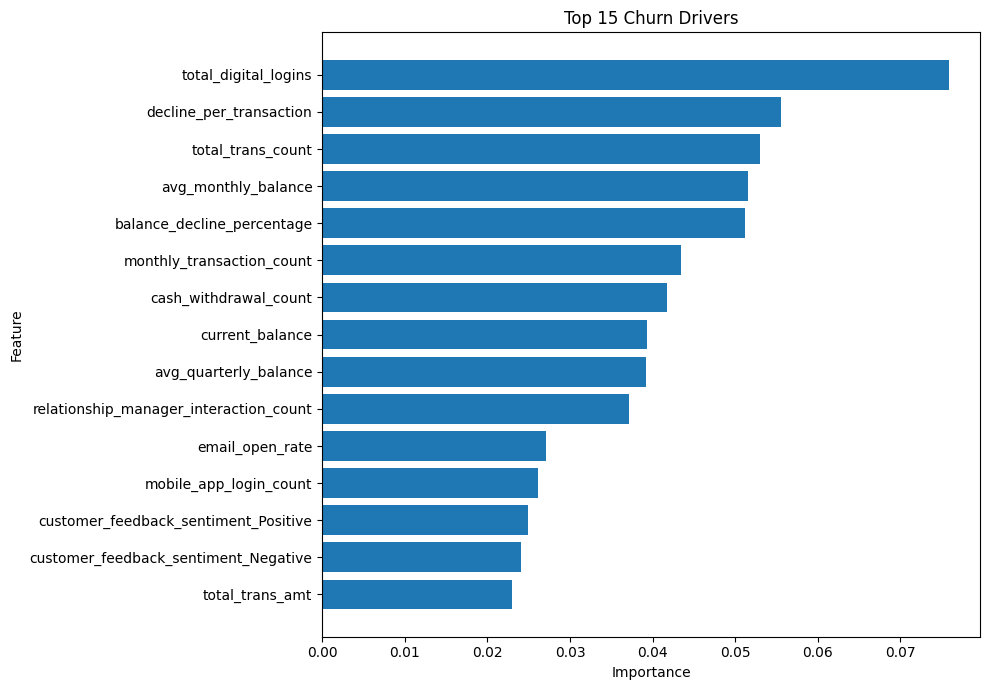

In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get trained random forest model
rf_model = clf_fe.named_steps["model"]

# Get preprocessor
preprocessor_trained = clf_fe.named_steps["preprocessor"]

# Get numerical feature names
num_feature_names = num_cols_fe

# Get one-hot encoded categorical feature names
cat_encoder = preprocessor_trained.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols_fe).tolist()

# Combine all feature names
all_feature_names = num_feature_names + cat_feature_names

# Feature importance values
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("Top 20 important features:")
display(feature_importance_df.head(20))

# Plot top 15
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values(by="importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Churn Drivers")
plt.tight_layout()
plt.show()

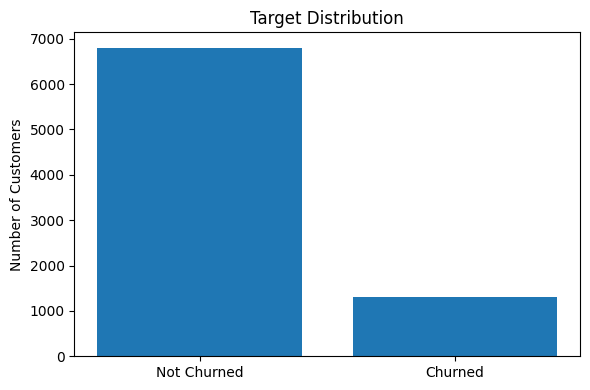

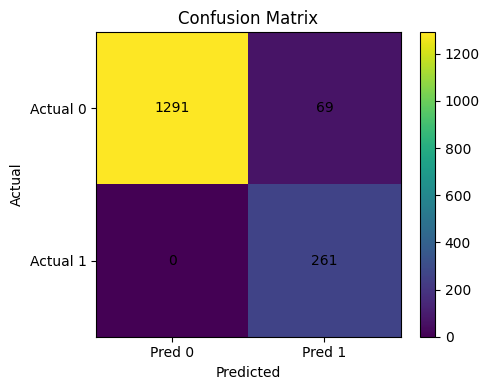

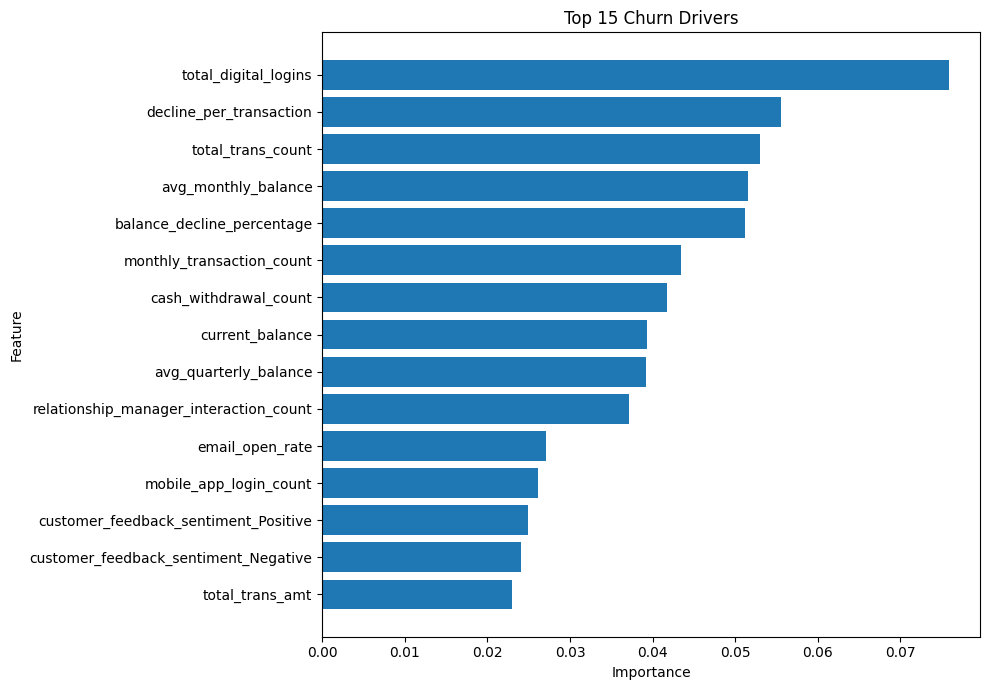

In [17]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Target distribution chart
target_counts = train_fe["churn"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not Churned", "Churned"], target_counts.values)
plt.title("Target Distribution")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=300)
plt.show()


# 2. Confusion matrix chart for final validation threshold
final_threshold = 0.10
final_val_preds = (val_probs_fe >= final_threshold).astype(int)

cm = confusion_matrix(y_val_fe, final_val_preds)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Pred 0", "Pred 1"])
plt.yticks(tick_marks, ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()


# 3. Top feature importance chart
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values(by="importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Churn Drivers")
plt.tight_layout()
plt.savefig("top_churn_drivers.png", dpi=300)
plt.show()

In [19]:
# FINAL SUBMISSION

best_threshold_final = 0.10

# Train final model on full feature-engineered training data
clf_fe.fit(X_fe, y_fe)

# Predict on feature-engineered test data
test_probs_final = clf_fe.predict_proba(X_test_fe)[:, 1]
test_preds_final = (test_probs_final >= best_threshold_final).astype(int)

# Create final submission
submission_final = pd.DataFrame({
    "customer_id": test_fe[id_col],
    "churn_prediction": test_preds_final,
    "churn_probability": test_probs_final
})

# Validate final submission
assert submission_final.shape[0] == 2026, "Submission must have exactly 2026 rows"
assert submission_final["churn_prediction"].isnull().sum() == 0, "churn_prediction has null values"
assert submission_final["churn_probability"].isnull().sum() == 0, "churn_probability has null values"
assert submission_final["churn_prediction"].isin([0, 1]).all(), "Predictions must be 0 or 1"
assert submission_final["churn_probability"].between(0, 1).all(), "Probabilities must be between 0 and 1"

# Save file
submission_final.to_csv("ChurnZero_Varun_Predictions.csv", index=False)

print("Final submission file created successfully.")
print("Shape:", submission_final.shape)
print("Prediction counts:")
print(submission_final["churn_prediction"].value_counts())
print("Probability range:", submission_final["churn_probability"].min(), "to", submission_final["churn_probability"].max())

Final submission file created successfully.
Shape: (2026, 3)
Prediction counts:
churn_prediction
0    1624
1     402
Name: count, dtype: int64
Probability range: 0.0 to 0.9975


## Validation Results

The final Random Forest model with engineered features achieved strong validation performance.

- PR-AUC: 0.999
- Selected threshold: 0.10
- Precision: 0.7909
- Recall: 1.0000
- F1-score: 0.8832
- False Positives: 69
- False Negatives: 0
- Business Cost: ₹34,500

The selected threshold achieved zero false negatives on the validation set, which is important because false negatives carry a much higher business cost.